In [1]:
# ==========================================================
# Imports
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.io import loadmat
from scipy.optimize import linprog
from scipy.sparse import lil_matrix, csr_matrix

Loading Early Data

In [2]:
# ==========================================================
# Load yearly OSOPSS data
#
# Time resolution:
#   Td = 1 hour
#
# Number of samples:
#   N = 8760
#
# This matches Lecture 07 yearly sizing formulation.
# ==========================================================

load_mat = loadmat("../data/raw/load_yearly.mat")
pv_mat = loadmat("../data/raw/PV_production_yearly.mat")
price_mat = loadmat("../data/raw/prices_yearly.mat")

load_year = load_mat["load_all_year"].flatten()
pv_factor = pv_mat["zeta_PV"].flatten()
price_year = price_mat["prices_all_year"].flatten()

Td = 1.0
N = len(load_year)

print("N:", N)
print("Load shape:", load_year.shape)
print("PV factor shape:", pv_factor.shape)
print("Price shape:", price_year.shape)

N: 8760
Load shape: (8760,)
PV factor shape: (8760,)
Price shape: (8760,)


Electricity Prices

In [3]:
# ==========================================================
# Electricity price model
#
# Same logic as the MATLAB OSOPSS code:
#
# p_E_plus  = price for buying electricity from grid
# p_E_minus = price/revenue for selling electricity to grid
#
# Import price is higher because of supplier and grid fees.
# Export price is lower.
# ==========================================================

payment_to_supplier_upscaling = 1.1
payment_from_supplier_downscaling = 0.9

p_supply_plus = np.zeros(N)
p_supply_minus = np.zeros(N)

for k in range(N):

    if price_year[k] >= 0:

        p_supply_plus[k] = (
            payment_to_supplier_upscaling
            * price_year[k]
        )

        p_supply_minus[k] = (
            payment_from_supplier_downscaling
            * price_year[k]
        )

    else:

        p_supply_plus[k] = (
            payment_from_supplier_downscaling
            * price_year[k]
        )

        p_supply_minus[k] = (
            payment_to_supplier_upscaling
            * price_year[k]
        )

p_grid_fee_plus = 0.05
p_grid_fee_minus = -0.01

p_E_plus = p_supply_plus + p_grid_fee_plus
p_E_minus = p_supply_minus + p_grid_fee_minus

print("Import price min/max:", p_E_plus.min(), p_E_plus.max())
print("Export price min/max:", p_E_minus.min(), p_E_minus.max())

Import price min/max: -0.040638999999999995 1.042442
Export price min/max: -0.120781 0.801998


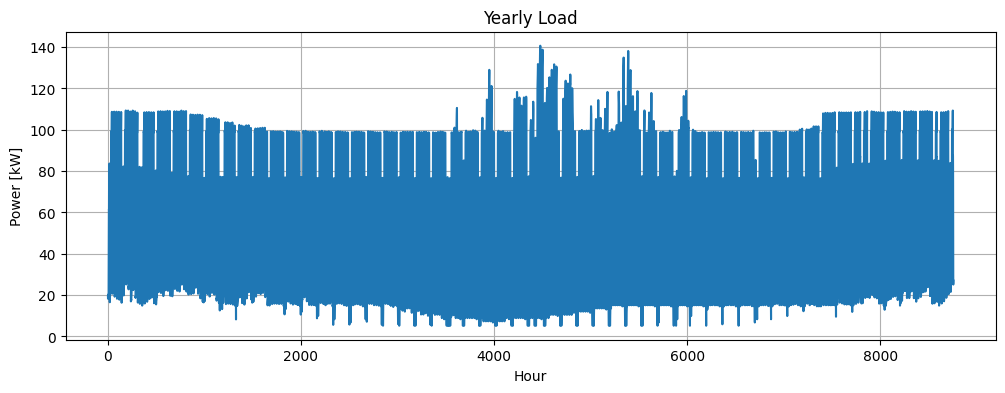

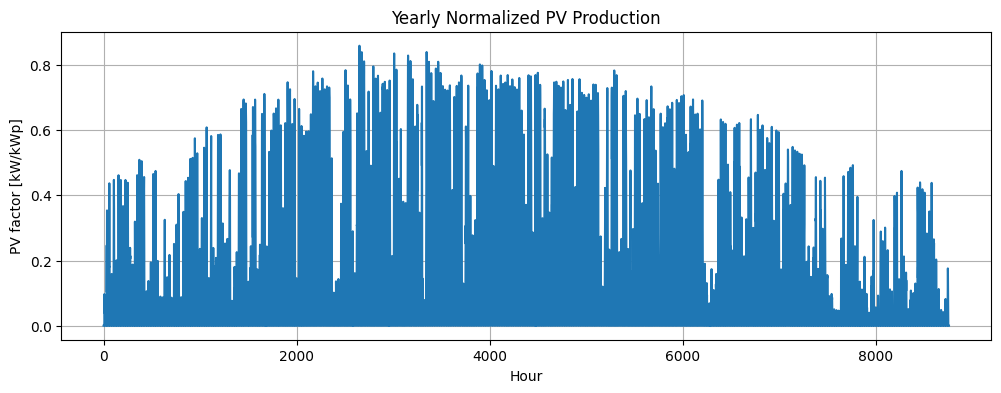

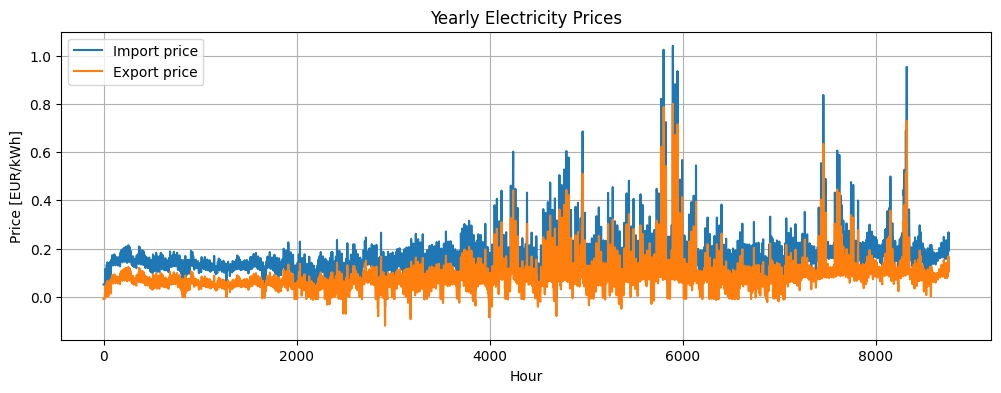

In [4]:
# ==========================================================
# Plot yearly inputs
# ==========================================================

plt.figure(figsize=(12,4))
plt.plot(load_year)
plt.title("Yearly Load")
plt.xlabel("Hour")
plt.ylabel("Power [kW]")
plt.grid()
plt.show()

plt.figure(figsize=(12,4))
plt.plot(pv_factor)
plt.title("Yearly Normalized PV Production")
plt.xlabel("Hour")
plt.ylabel("PV factor [kW/kWp]")
plt.grid()
plt.show()

plt.figure(figsize=(12,4))
plt.plot(p_E_plus, label="Import price")
plt.plot(p_E_minus, label="Export price")
plt.title("Yearly Electricity Prices")
plt.xlabel("Hour")
plt.ylabel("Price [EUR/kWh]")
plt.grid()
plt.legend()
plt.show()

Economic and system parameters

In [10]:
# ==========================================================
# Economic and technical parameters
# Based on the OSOPSS yearly sizing formulation
# ==========================================================

# Peak power price
p_pp = 4.0  # [EUR/kW]

# Grid connection
P_grid_max = 150.0              # existing grid limit [kW]
P_grid_max_delta_grid = 200.0   # maximum possible enlarged limit [kW]

# PV system
S_PV_max = 750.0                # maximum PV size [kWp]
p_PV_inv = 1100.0               # [EUR/kWp]
p_PV_mnt = 20.0                 # [EUR/kWp/year]
N_PV_LT = 25                    # [years]
p_PV_rpl = 900.0                # [EUR/kWp]

# BESS
eta_BESS_ch = 0.9
eta_BESS_dch = 0.9
DoD_max = 0.85
beta_batt = 2.0                 # converter-to-battery sizing factor [1/h]

p_batt_inv = 300.0              # [EUR/kWh]
p_PC_inv = 240.0                # [EUR/kW]
p_batt_mnt = 7.0                # [EUR/kWh/year]
p_PC_mnt = 6.0                  # [EUR/kW/year]

N_PC_LT = 17
p_PC_rpl = 180.0

N_batt_LT = 15
p_batt_rpl = 210.0
N_cyc = 6500

# Investment evaluation
N_payoff = 20
N_DL = 25
CAPEX_max = 1e9

Degenerative prices

In [11]:
# ==========================================================
# Degradation / replacement annualized terms
# ==========================================================

p_PV_deg = ((N_DL - N_PV_LT) / (N_DL * N_PV_LT)) * p_PV_rpl
p_PC_deg = ((N_DL - N_PC_LT) / (N_DL * N_PC_LT)) * p_PC_rpl
p_batt_deg = ((N_DL - N_batt_LT) / (N_DL * N_batt_LT)) * p_batt_rpl

print("PV degradation cost:", p_PV_deg)
print("PC degradation cost:", p_PC_deg)
print("Battery degradation cost:", p_batt_deg)

PV degradation cost: 0.0
PC degradation cost: 3.3882352941176466
Battery degradation cost: 5.6000000000000005


Variable Indexing 

In [12]:
# ==========================================================
# Decision variable vector
#
# z = [
#   S_PV,
#   S_batt,
#   S_PC,
#   P_grid_delta,
#   E_BESS[0:N],
#   P_PV[0:N],
#   P_BESS_ch[0:N],
#   P_BESS_dch[0:N],
#   eps_E[0:N],
#   eps_pp[0:12],
#   C_batt_deg,
#   C_grid_inv
# ]
# ==========================================================

idx_S_PV = 0
idx_S_batt = 1
idx_S_PC = 2
idx_P_grid_delta = 3

idx_E_start = 4
idx_P_PV_start = idx_E_start + N
idx_P_ch_start = idx_P_PV_start + N
idx_P_dch_start = idx_P_ch_start + N
idx_eps_E_start = idx_P_dch_start + N
idx_eps_pp_start = idx_eps_E_start + N
idx_C_batt_deg = idx_eps_pp_start + 12
idx_C_grid_inv = idx_C_batt_deg + 1

n_vars = idx_C_grid_inv + 1

print("Number of optimization variables:", n_vars)

Number of optimization variables: 43818


Now we compute the no-investment baseline cost, because OSOPSS uses it for the payoff contraints 

# NO Investment Baseline

In [18]:
# ==========================================================
# Baseline without PV/BESS investment
#
# This represents the annual operating cost if the building
# only uses the grid.
#
# It includes:
# - energy cost
# - monthly peak power cost
# ==========================================================

# Energy cost without investment
J_E_noinv = np.sum(
    np.maximum(
        p_E_plus * load_year * Td,
        p_E_minus * load_year * Td
    )
)

# Month lengths
number_of_days_in_month = np.array(
    [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
)

# Starting hour indices of each month
month_start = np.concatenate(
    ([0], np.cumsum(number_of_days_in_month) * 24)
)

P_pp_noinv = []

for j in range(12):

    start = month_start[j]
    end = month_start[j + 1]

    monthly_peak = np.max(
        load_year[start:end]
    )

    P_pp_noinv.append(monthly_peak)

P_pp_noinv = np.array(P_pp_noinv)

J_pp_noinv = p_pp * np.sum(P_pp_noinv)

OPEX_noinv = J_E_noinv + J_pp_noinv

print("Energy cost without investment [EUR/year]:", J_E_noinv)
print("Peak power cost without investment [EUR/year]:", J_pp_noinv)
print("OPEX without investment [EUR/year]:", OPEX_noinv)

Energy cost without investment [EUR/year]: 78762.0931949811
Peak power cost without investment [EUR/year]: 5505.911150202
OPEX without investment [EUR/year]: 84268.0043451831


In [19]:
# ==========================================================
# Objective function
#
# Minimize:
#
# OPEX_inv + CAPEX / N_DL
#
# This corresponds to Lecture 07:
#
# J = OPEX_inv + CAPEX / design_lifetime
# ==========================================================

c = np.zeros(n_vars)

# PV annualized + maintenance + degradation
c[idx_S_PV] = (
    p_PV_mnt
    + p_PV_deg
    + p_PV_inv / N_DL
)

# Battery annualized + maintenance
c[idx_S_batt] = (
    p_batt_mnt
    + p_batt_inv / N_DL
)

# Power converter annualized + maintenance + degradation
c[idx_S_PC] = (
    p_PC_mnt
    + p_PC_deg
    + p_PC_inv / N_DL
)

# eps_E represents yearly energy cost
c[idx_eps_E_start : idx_eps_E_start + N] = 1.0

# monthly peak power cost
c[idx_eps_pp_start : idx_eps_pp_start + 12] = p_pp

# battery degradation auxiliary cost
c[idx_C_batt_deg] = 1.0

# grid investment annualized cost
c[idx_C_grid_inv] = 1.0 / N_DL

print("Objective vector shape:", c.shape)

Objective vector shape: (43818,)


# OPEX_noinv = 84,268 EUR/year

In [25]:
# ==========================================================
# Initialize inequality constraints
#
# We will build:
#
# A_ub @ z <= b_ub
#
# Because the problem is large, we use sparse matrices.
# ==========================================================

A_ub_rows = []
b_ub_vals = []

print("Ready to build inequality constraints")

Ready to build inequality constraints


In [26]:
# ==========================================================
# Helper function for sparse constraint rows
#
# Instead of creating huge dense vectors of length 43818,
# we store only nonzero entries:
#
# row_indices = variable indices
# row_values  = coefficients
# rhs         = right-hand side
# ==========================================================

def add_ineq(row_indices, row_values, rhs):
    A_ub_rows.append((row_indices, row_values))
    b_ub_vals.append(rhs)

In [27]:
# ==========================================================
# ENERGY COST AUXILIARY CONSTRAINTS
#
# eps_E[k] must be greater than the cost expression
# for both import and export price cases.
#
# This linearizes:
#
# energy_cost[k] = max(
#     p_E_plus[k]  * grid_power[k] * Td,
#     p_E_minus[k] * grid_power[k] * Td
# )
#
# where:
#
# grid_power = load - PV + BESS_ch - BESS_dch
#
# ==========================================================

for k in range(N):

    # ------------------------------------------------------
    # Constraint using p_E_plus
    # ------------------------------------------------------
    # p_E_plus[k] * (load - PV + ch - dch) * Td <= eps_E[k]
    #
    # Rearranged:
    # -p_E_plus*PV*Td
    # +p_E_plus*ch*Td
    # -p_E_plus*dch*Td
    # -eps_E <= -p_E_plus*load*Td
    # ------------------------------------------------------

    add_ineq(
        row_indices=[
            idx_P_PV_start + k,
            idx_P_ch_start + k,
            idx_P_dch_start + k,
            idx_eps_E_start + k
        ],
        row_values=[
            -p_E_plus[k] * Td,
             p_E_plus[k] * Td,
            -p_E_plus[k] * Td,
            -1.0
        ],
        rhs=-p_E_plus[k] * load_year[k] * Td
    )

    # ------------------------------------------------------
    # Constraint using p_E_minus
    # ------------------------------------------------------

    add_ineq(
        row_indices=[
            idx_P_PV_start + k,
            idx_P_ch_start + k,
            idx_P_dch_start + k,
            idx_eps_E_start + k
        ],
        row_values=[
            -p_E_minus[k] * Td,
             p_E_minus[k] * Td,
            -p_E_minus[k] * Td,
            -1.0
        ],
        rhs=-p_E_minus[k] * load_year[k] * Td
    )

print("Constraints after energy cost:", len(A_ub_rows))

Constraints after energy cost: 17520


Monthly peak constraints

In [33]:
# ==========================================================
# MONTHLY PEAK POWER CONSTRAINTS
#
# eps_pp[j] represents the peak grid import power
# during month j.
#
# For every hour k in month j:
#
# grid_power[k] <= eps_pp[j]
#
# where:
#
# grid_power = load - PV + BESS_ch - BESS_dch
#
# Rearranged:
#
# -P_PV[k] + P_ch[k] - P_dch[k] - eps_pp[j]
# <= -load[k]
# ==========================================================

for j in range(12):

    start = month_start[j]
    end = month_start[j + 1]

    for k in range(start, end):

        add_ineq(
            row_indices=[
                idx_P_PV_start + k,
                idx_P_ch_start + k,
                idx_P_dch_start + k,
                idx_eps_pp_start + j
            ],
            row_values=[
                -1.0,
                 1.0,
                -1.0,
                -1.0
            ],
            rhs=-load_year[k]
        )

print("Constraints after monthly peak:", len(A_ub_rows))

Constraints after monthly peak: 26280


In [34]:
# ==========================================================
# eps_pp[j] >= 0
#
# Written as:
#
# -eps_pp[j] <= 0
# ==========================================================

for j in range(12):

    add_ineq(
        row_indices=[
            idx_eps_pp_start + j
        ],
        row_values=[
            -1.0
        ],
        rhs=0.0
    )

print("Constraints after eps_pp nonnegativity:", len(A_ub_rows))

Constraints after eps_pp nonnegativity: 26292


Battery Degradation Constraints

In [38]:
# ==========================================================
# BATTERY DEGRADATION AUXILIARY CONSTRAINTS
#
# C_batt_deg is an auxiliary variable.
#
# It must be large enough to cover:
#
# 1) Calendar degradation cost depending on battery size
# 2) Cycle degradation cost depending on battery throughput
# ==========================================================

# ----------------------------------------------------------
# Calendar degradation:
#
# p_batt_deg * S_batt <= C_batt_deg
#
# Rearranged:
# p_batt_deg * S_batt - C_batt_deg <= 0
# ----------------------------------------------------------

add_ineq(
    row_indices=[
        idx_S_batt,
        idx_C_batt_deg
    ],
    row_values=[
        p_batt_deg,
        -1.0
    ],
    rhs=0.0
)


# ----------------------------------------------------------
# Cycle degradation:
#
# This depends on yearly battery charge/discharge throughput.
# ----------------------------------------------------------

Pch_multiplier = (
    p_batt_rpl
    * eta_BESS_ch
    * Td
    / (2 * N_cyc * DoD_max)
)

Pdch_multiplier = (
    p_batt_rpl
    * Td
    / (2 * N_cyc * DoD_max * eta_BESS_dch)
)

row_indices = [idx_S_batt, idx_C_batt_deg]
row_values = [-p_batt_rpl / N_DL, -1.0]

for k in range(N):

    row_indices.append(idx_P_ch_start + k)
    row_values.append(Pch_multiplier)

    row_indices.append(idx_P_dch_start + k)
    row_values.append(Pdch_multiplier)

add_ineq(
    row_indices=row_indices,
    row_values=row_values,
    rhs=0.0
)

print("Constraints after battery degradation:", len(A_ub_rows))

Constraints after battery degradation: 26294


Grid Investment Constraints

In [39]:
# ==========================================================
# GRID INVESTMENT AUXILIARY CONSTRAINTS
#
# C_grid_inv is the cost of increasing grid connection capacity.
#
# We use:
#
# C_grid_inv >= p_grid_inv * P_grid_delta
# C_grid_inv >= p_grid_rev * P_grid_delta
#
# The second one allows possible residual/reversion value.
# In our case p_grid_rev = 0.
# ==========================================================

p_grid_inv = 230.0
p_grid_rev = 0.0

# p_grid_inv * P_grid_delta - C_grid_inv <= 0
add_ineq(
    row_indices=[
        idx_P_grid_delta,
        idx_C_grid_inv
    ],
    row_values=[
        p_grid_inv,
        -1.0
    ],
    rhs=0.0
)

# p_grid_rev * P_grid_delta - C_grid_inv <= 0
add_ineq(
    row_indices=[
        idx_P_grid_delta,
        idx_C_grid_inv
    ],
    row_values=[
        p_grid_rev,
        -1.0
    ],
    rhs=0.0
)

print("Constraints after grid investment:", len(A_ub_rows))

Constraints after grid investment: 26296


Done with the Economic Layer!
26296 constraints
43818 variables

In [43]:
# ==========================================================
# PV PRODUCTION LIMITS
#
# 0 <= P_PV(k) <= zeta_PV(k) * S_PV
#
# We only need the upper inequality because
# lower bound will later enforce P_PV >= 0.
#
# P_PV(k) - zeta_PV(k) * S_PV <= 0
# ==========================================================

for k in range(N):

    add_ineq(
        row_indices=[
            idx_S_PV,
            idx_P_PV_start + k
        ],
        row_values=[
            -pv_factor[k],
             1.0
        ],
        rhs=0.0
    )

print("Constraints after PV limits:", len(A_ub_rows))

Constraints after PV limits: 35056


PV maximum size 

In [44]:
# ==========================================================
# PV SIZE LIMIT
#
# S_PV <= S_PV_max
# ==========================================================

add_ineq(
    row_indices=[
        idx_S_PV
    ],
    row_values=[
        1.0
    ],
    rhs=S_PV_max
)

print("Constraints after PV size limit:", len(A_ub_rows))

Constraints after PV size limit: 35057


Grid upgrade limit

In [45]:
# ==========================================================
# GRID UPGRADE LIMIT
#
# P_grid_delta <= P_grid_max_delta_grid
# ==========================================================

add_ineq(
    row_indices=[
        idx_P_grid_delta
    ],
    row_values=[
        1.0
    ],
    rhs=P_grid_max_delta_grid
)

print("Constraints after grid upgrade limit:", len(A_ub_rows))


Constraints after grid upgrade limit: 35058


Battery Energy Capacity Limits

In [46]:
# ==========================================================
# BATTERY ENERGY CAPACITY LIMITS
# ==========================================================
#
# In the OSOPSS sizing model, S_batt is the selected battery
# capacity [kWh].
#
# The battery energy state E_BESS[k] must remain within:
#
#   (1 - DoD_max) * S_batt <= E_BESS[k] <= S_batt
#
# Lower limit:
#   (1 - DoD_max) * S_batt - E_BESS[k] <= 0
#
# Upper limit:
#   -S_batt + E_BESS[k] <= 0
# ==========================================================

for k in range(N):

    # ------------------------------------------------------
    # Lower energy limit
    # ------------------------------------------------------

    add_ineq(
        row_indices=[
            idx_S_batt,
            idx_E_start + k
        ],
        row_values=[
            (1 - DoD_max),
            -1.0
        ],
        rhs=0.0
    )

    # ------------------------------------------------------
    # Upper energy limit
    # ------------------------------------------------------

    add_ineq(
        row_indices=[
            idx_S_batt,
            idx_E_start + k
        ],
        row_values=[
            -1.0,
             1.0
        ],
        rhs=0.0
    )

print("Constraints after battery energy limits:", len(A_ub_rows))

Constraints after battery energy limits: 52578


Power charge/Discharge power linked to converter size

In [47]:
# ==========================================================
# BESS POWER CONVERTER LIMITS
# ==========================================================
#
# The converter size S_PC [kW] limits battery charge/discharge.
#
# P_BESS_ch[k] + P_BESS_dch[k] <= S_PC
#
# Rearranged:
#
# -S_PC + P_BESS_ch[k] + P_BESS_dch[k] <= 0
#
# This also prevents the optimizer from using more battery power
# than the selected converter can physically provide.
# ==========================================================

for k in range(N):

    add_ineq(
        row_indices=[
            idx_S_PC,
            idx_P_ch_start + k,
            idx_P_dch_start + k
        ],
        row_values=[
            -1.0,
             1.0,
             1.0
        ],
        rhs=0.0
    )

print("Constraints after converter power limits:", len(A_ub_rows))

Constraints after converter power limits: 61338


Converter to Battery sizing relation

In [48]:
# ==========================================================
# CONVERTER / BATTERY SIZE RELATION
# ==========================================================
#
# The MATLAB OSOPSS model uses:
#
# S_PC <= beta_batt * S_batt
#
# Rearranged:
#
# -beta_batt * S_batt + S_PC <= 0
#
# This prevents the optimizer from choosing an unrealistically
# large converter for a tiny battery.
# ==========================================================

add_ineq(
    row_indices=[
        idx_S_batt,
        idx_S_PC
    ],
    row_values=[
        -beta_batt,
         1.0
    ],
    rhs=0.0
)

print("Constraints after converter/battery relation:", len(A_ub_rows))

Constraints after converter/battery relation: 61339


Grid Connection Constraints

In [49]:
# ==========================================================
# GRID CONNECTION CONSTRAINTS
# ==========================================================
#
# Grid power:
#
# P_grid[k] = load[k] - P_PV[k] + P_ch[k] - P_dch[k]
#
# The grid exchange must stay within:
#
# -P_grid_max - P_grid_delta <= P_grid[k]
#  P_grid[k] <= P_grid_max + P_grid_delta
#
# P_grid_delta is an optimization variable that represents
# additional grid capacity investment.
# ==========================================================

for k in range(N):

    # ------------------------------------------------------
    # Upper grid import limit:
    #
    # P_grid[k] <= P_grid_max + P_grid_delta
    #
    # load - PV + ch - dch <= P_grid_max + P_grid_delta
    #
    # -PV + ch - dch - P_grid_delta <= P_grid_max - load
    # ------------------------------------------------------

    add_ineq(
        row_indices=[
            idx_P_PV_start + k,
            idx_P_ch_start + k,
            idx_P_dch_start + k,
            idx_P_grid_delta
        ],
        row_values=[
            -1.0,
             1.0,
            -1.0,
            -1.0
        ],
        rhs=P_grid_max - load_year[k]
    )

    # ------------------------------------------------------
    # Lower grid export limit:
    #
    # P_grid[k] >= -P_grid_max - P_grid_delta
    #
    # -P_grid[k] <= P_grid_max + P_grid_delta
    #
    # -load + PV - ch + dch <= P_grid_max + P_grid_delta
    #
    # PV - ch + dch - P_grid_delta <= P_grid_max + load
    # ------------------------------------------------------

    add_ineq(
        row_indices=[
            idx_P_PV_start + k,
            idx_P_ch_start + k,
            idx_P_dch_start + k,
            idx_P_grid_delta
        ],
        row_values=[
             1.0,
            -1.0,
             1.0,
            -1.0
        ],
        rhs=P_grid_max + load_year[k]
    )

print("Constraints after grid connection limits:", len(A_ub_rows))

Constraints after grid connection limits: 78859


In [50]:
# ==========================================================
# EQUALITY CONSTRAINTS
#
# These are used for BESS energy dynamics.
# ==========================================================

A_eq_rows = []
b_eq_vals = []

def add_eq(row_indices, row_values, rhs):
    A_eq_rows.append((row_indices, row_values))
    b_eq_vals.append(rhs)

print("Ready to build equality constraints")

Ready to build equality constraints


BESS cyclic dynamics

In [51]:
# ==========================================================
# BATTERY ENERGY DYNAMICS
# ==========================================================
#
# For k = 0,...,N-2:
#
# E[k+1] = E[k]
#          + eta_ch * Td * P_ch[k]
#          - Td / eta_dch * P_dch[k]
#
# Rearranged:
#
# E[k] - E[k+1]
# + eta_ch * Td * P_ch[k]
# - Td/eta_dch * P_dch[k] = 0
#
# The final constraint enforces cyclic operation:
#
# E[0] = E[N-1] + eta_ch*Td*P_ch[N-1]
#                 - Td/eta_dch*P_dch[N-1]
#
# This prevents the optimizer from emptying the battery at the
# end of the year for artificial savings.
# ==========================================================

# Dynamics for k = 0 to N-2
for k in range(N - 1):

    add_eq(
        row_indices=[
            idx_E_start + k,
            idx_E_start + k + 1,
            idx_P_ch_start + k,
            idx_P_dch_start + k
        ],
        row_values=[
             1.0,
            -1.0,
             eta_BESS_ch * Td,
            -Td / eta_BESS_dch
        ],
        rhs=0.0
    )

# Cyclic final condition
add_eq(
    row_indices=[
        idx_E_start + N - 1,
        idx_E_start + 0,
        idx_P_ch_start + N - 1,
        idx_P_dch_start + N - 1
    ],
    row_values=[
         1.0,
        -1.0,
         eta_BESS_ch * Td,
        -Td / eta_BESS_dch
    ],
    rhs=0.0
)

print("Number of equality constraints:", len(A_eq_rows))

Number of equality constraints: 8760


Payoff constraints

In [52]:
# ==========================================================
# PAYOFF CONSTRAINT
# ==========================================================
#
# The investment must pay off within N_payoff years.
#
# From Lecture 07:
#
# OPEX_inv + CAPEX / N_payoff <= OPEX_noinv
#
# This prevents the optimizer from choosing a system that is
# technically good but economically unjustified.
# ==========================================================

row_indices = [
    idx_S_PV,
    idx_S_batt,
    idx_S_PC,
    idx_C_batt_deg,
    idx_C_grid_inv
]

row_values = [
    p_PV_mnt + p_PV_deg + p_PV_inv / N_payoff,
    p_batt_mnt + p_batt_inv / N_payoff,
    p_PC_mnt + p_PC_deg + p_PC_inv / N_payoff,
    1.0,
    1.0 / N_payoff
]

# Energy cost terms
for k in range(N):
    row_indices.append(idx_eps_E_start + k)
    row_values.append(1.0)

# Monthly peak power terms
for j in range(12):
    row_indices.append(idx_eps_pp_start + j)
    row_values.append(p_pp)

add_ineq(
    row_indices=row_indices,
    row_values=row_values,
    rhs=OPEX_noinv
)

print("Constraints after payoff constraint:", len(A_ub_rows))

Constraints after payoff constraint: 78860


CAPEX limit

In [53]:
# ==========================================================
# CAPEX LIMIT
# ==========================================================
#
# Total investment must not exceed CAPEX_max.
#
# CAPEX =
# PV investment
# + battery investment
# + power converter investment
# + grid investment
# ==========================================================

add_ineq(
    row_indices=[
        idx_S_PV,
        idx_S_batt,
        idx_S_PC,
        idx_C_grid_inv
    ],
    row_values=[
        p_PV_inv,
        p_batt_inv,
        p_PC_inv,
        1.0
    ],
    rhs=CAPEX_max
)

print("Constraints after CAPEX limit:", len(A_ub_rows))

Constraints after CAPEX limit: 78861


Converting sparse constraints

In [54]:
# ==========================================================
# Convert sparse constraint lists into scipy sparse matrices
# ==========================================================

from scipy.sparse import lil_matrix

A_ub = lil_matrix(
    (len(A_ub_rows), n_vars)
)

for r, (cols, vals) in enumerate(A_ub_rows):
    A_ub[r, cols] = vals

A_ub = A_ub.tocsr()

b_ub = np.array(b_ub_vals)

A_eq = lil_matrix(
    (len(A_eq_rows), n_vars)
)

for r, (cols, vals) in enumerate(A_eq_rows):
    A_eq[r, cols] = vals

A_eq = A_eq.tocsr()

b_eq = np.array(b_eq_vals)

print("A_ub shape:", A_ub.shape)
print("b_ub shape:", b_ub.shape)

print("A_eq shape:", A_eq.shape)
print("b_eq shape:", b_eq.shape)

A_ub shape: (78861, 43818)
b_ub shape: (78861,)
A_eq shape: (8760, 43818)
b_eq shape: (8760,)


Variable Bounds

In [55]:
# ==========================================================
# VARIABLE BOUNDS
# ==========================================================
#
# Most variables are non-negative.
#
# Size variables:
#   S_PV >= 0
#   S_batt >= 0
#   S_PC >= 0
#   P_grid_delta can be negative or positive in the MATLAB code,
#   but here we keep it >= 0 because it represents enlargement.
#
# Operation variables:
#   E_BESS >= 0
#   P_PV >= 0
#   P_ch >= 0
#   P_dch >= 0
#   eps_E free? In practice cost can be negative when exporting,
#   so allow eps_E to be unbounded below.
#   eps_pp >= 0
#   C_batt_deg >= 0
#   C_grid_inv >= 0
# ==========================================================

bounds = []

# S_PV
bounds.append((0, None))

# S_batt
bounds.append((0, None))

# S_PC
bounds.append((0, None))

# P_grid_delta
bounds.append((0, P_grid_max_delta_grid))

# E_BESS[k]
for k in range(N):
    bounds.append((0, None))

# P_PV[k]
for k in range(N):
    bounds.append((0, None))

# P_BESS_ch[k]
for k in range(N):
    bounds.append((0, None))

# P_BESS_dch[k]
for k in range(N):
    bounds.append((0, None))

# eps_E[k]
for k in range(N):
    bounds.append((None, None))

# eps_pp[j]
for j in range(12):
    bounds.append((0, None))

# C_batt_deg
bounds.append((0, None))

# C_grid_inv
bounds.append((0, None))

print("Number of bounds:", len(bounds))
print("Number of variables:", n_vars)

Number of bounds: 43818
Number of variables: 43818


Solving the sizing LP

In [56]:
# ==========================================================
# SOLVE JOINT PV+BESS SIZING AND OPERATION LP
#
# This is the main optimization of Notebook 13.
# ==========================================================

result = linprog(
    c=c,
    A_ub=A_ub,
    b_ub=b_ub,
    A_eq=A_eq,
    b_eq=b_eq,
    bounds=bounds,
    method="highs"
)

print("Solver success:", result.success)
print("Solver message:", result.message)

if result.success:
    print("Optimal objective [EUR/year]:", result.fun)

Solver success: True
Solver message: Optimization terminated successfully. (HiGHS Status 7: Optimal)
Optimal objective [EUR/year]: 63166.25323649002


Extract sizing results

In [57]:
# ==========================================================
# EXTRACT OPTIMAL SIZES
# ==========================================================

z = result.x

S_PV_opt = z[idx_S_PV]
S_batt_opt = z[idx_S_batt]
S_PC_opt = z[idx_S_PC]
P_grid_delta_opt = z[idx_P_grid_delta]

print("Optimal PV size [kWp]:", S_PV_opt)
print("Optimal battery size [kWh]:", S_batt_opt)
print("Optimal converter size [kW]:", S_PC_opt)
print("Optimal grid enlargement [kW]:", P_grid_delta_opt)

Optimal PV size [kWp]: 588.76677924684
Optimal battery size [kWh]: 403.42584553383693
Optimal converter size [kW]: 103.25371980674049
Optimal grid enlargement [kW]: 87.89778114714437


In [58]:
# ==========================================================
# EXTRACT OPERATION VARIABLES   ~ Extract yearly operation.
# ==========================================================

E_opt = z[idx_E_start : idx_E_start + N]

P_PV_opt = z[
    idx_P_PV_start :
    idx_P_PV_start + N
]

P_ch_opt = z[
    idx_P_ch_start :
    idx_P_ch_start + N
]

P_dch_opt = z[
    idx_P_dch_start :
    idx_P_dch_start + N
]

print("Done.")

Done.


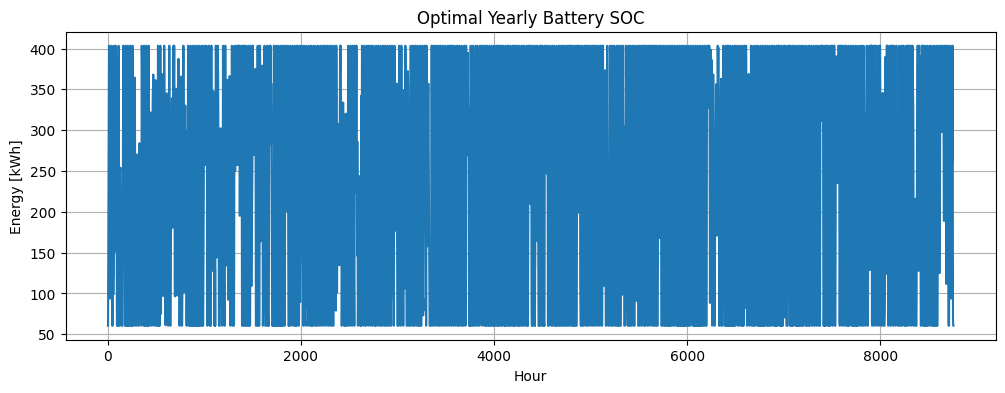

In [59]:
plt.figure(figsize=(12,4))
plt.plot(E_opt)

plt.title("Optimal Yearly Battery SOC")
plt.xlabel("Hour")
plt.ylabel("Energy [kWh]")
plt.grid()

plt.show()

In [60]:
z = result.x

S_PV_opt = z[idx_S_PV]
S_batt_opt = z[idx_S_batt]
S_PC_opt = z[idx_S_PC]
P_grid_delta_opt = z[idx_P_grid_delta]

print("Optimal PV size [kWp]:", S_PV_opt)
print("Optimal battery size [kWh]:", S_batt_opt)
print("Optimal converter size [kW]:", S_PC_opt)
print("Optimal grid enlargement [kW]:", P_grid_delta_opt)

Optimal PV size [kWp]: 588.76677924684
Optimal battery size [kWh]: 403.42584553383693
Optimal converter size [kW]: 103.25371980674049
Optimal grid enlargement [kW]: 87.89778114714437


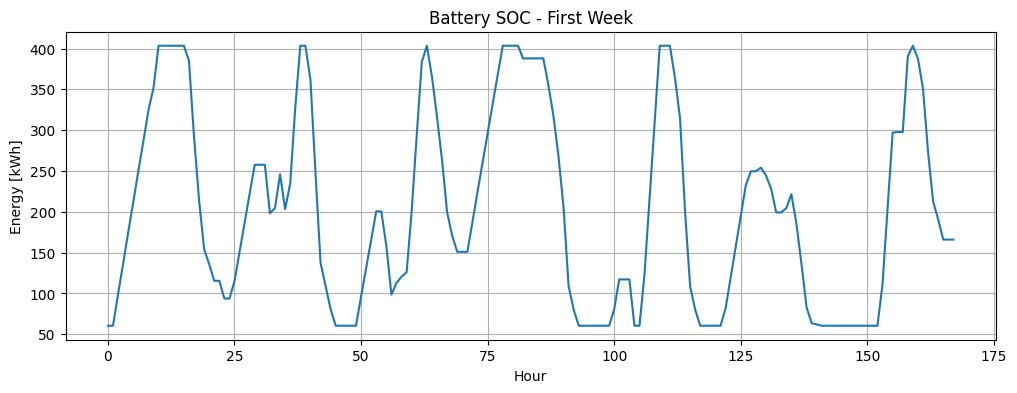

In [63]:
week = slice(0, 24*7)

plt.figure(figsize=(12,4))
plt.plot(E_opt[week])

plt.title("Battery SOC - First Week")
plt.xlabel("Hour")
plt.ylabel("Energy [kWh]")
plt.grid()

plt.show()

In [64]:
optimal_sizes = pd.DataFrame([{
    "S_PV_kWp": S_PV_opt,
    "S_batt_kWh": S_batt_opt,
    "S_PC_kW": S_PC_opt,
    "P_grid_delta_kW": P_grid_delta_opt,
    "OPEX_noinv_EUR_per_year": OPEX_noinv,
    "Optimal_objective_EUR_per_year": result.fun,
    "Estimated_annual_saving_EUR": OPEX_noinv - result.fun
}])

optimal_sizes.to_csv(
    "../results/tables/optimal_PV_BESS_sizing_OSOPSS.csv",
    index=False
)

optimal_sizes

,S_PV_kWp,S_batt_kWh,S_PC_kW,P_grid_delta_kW,OPEX_noinv_EUR_per_year,Optimal_objective_EUR_per_year,Estimated_annual_saving_EUR
0,588.766779,403.425846,103.25372,87.897781,84268.004345,63166.253236,21101.751109
